# Virtual PCells

A **Virtual PCell** (`VKCell`, short for *Virtual KCell*) is an in-memory PCell
whose geometry lives entirely in floating-point micrometres — no KLayout
database, no DBU conversion, until you explicitly materialise it.

```
┌──────────────────────────────────────────────┐
│               VKCell (µm)                    │
│  ┌──────────┐   ┌──────────┐                 │
│  │ VInstance│   │ VShapes  │  DPolygon, DBox │
│  └──────────┘   └──────────┘                 │
│        │             │                       │
│        ▼             ▼                       │
│   insert_into(real_kcell)                    │
└──────────────────────────────────────────────┘
          │
          ▼
   KCell (DBU, KLayout-backed)
```

## When to use VKCell

| Use case | Recommended cell type |
|---|---|
| Production GDS, routing into a final layout | `KCell` |
| All-angle routing backbone computation | `VKCell` |
| Preview / inspect before committing geometry | `VKCell` |
| Factory functions that need composition before materialisation | `VKCell` |

## Key differences vs KCell

| Property | `VKCell` | `KCell` |
|---|---|---|
| Coordinates | float µm | integer DBU |
| Backed by KLayout cell DB | No — pure Python | Yes |
| Shape type | `VShapes` (`DPolygon`, `DBox`, …) | `klayout.db.Shapes` |
| `@kf.vcell` / `kcl.vcell` decorator | Yes | No (`@kf.cell`) |
| Must call `insert_into()` to materialise | Yes | — |

## Setup

In [1]:
from functools import partial

import kfactory as kf
from kfactory.factories.virtual.euler import virtual_bend_euler_factory
from kfactory.factories.virtual.straight import virtual_straight_factory


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()

# Use a dedicated KCLayout so the virtual factories' layer indices are consistent
pdk = kf.KCLayout("virtual_demo", infos=LAYER)

## Creating a VKCell directly

`kcl.vkcell(name=...)` returns an empty VKCell attached to the given layout.
Shapes are added via `vkcell.shapes(layer_index).insert(...)` using µm-based
`DPolygon` / `DBox` objects.

In [2]:
vc_box = pdk.vkcell(name="simple_box")

layer_idx = pdk.layer(L.WG)

# Insert a rectangle in µm
vc_box.shapes(layer_idx).insert(kf.kdb.DBox(0, -0.25, 10.0, 0.25))

print(f"VKCell name  : {vc_box.name}")
print(f"bbox (µm)    : {vc_box.dbbox(layer_idx)}")
print(f"bbox (DBU)   : {vc_box.ibbox(layer_idx)}")
print(f"shapes count : {vc_box.shapes(layer_idx).size()}")

VKCell name  : simple_box
bbox (µm)    : (0,-0.25;10,0.25)
bbox (DBU)   : (0,-250;10000,250)
shapes count : 1


Notice that `ibbox` returns the bounding box in DBU (integer units), while
`dbbox` returns it in µm.  The two are consistent — multiplied by `pdk.dbu` (nm/µm).

## Ports on a VKCell

Ports are created with `create_port` using a `DCplxTrans` (µm-based complex
transform) to specify position and orientation.

In [3]:
vc_wg = pdk.vkcell(name="virtual_wg")
wg_layer = pdk.layer(L.WG)

vc_wg.shapes(wg_layer).insert(kf.kdb.DBox(0, -0.25, 20.0, 0.25))

# o1 faces west (angle=180°)
vc_wg.create_port(
    name="o1",
    dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, 0.0, 0.0),
    width=0.5,
    layer=wg_layer,
)
# o2 faces east (angle=0°)
vc_wg.create_port(
    name="o2",
    dcplx_trans=kf.kdb.DCplxTrans(1, 0, False, 20.0, 0.0),
    width=0.5,
    layer=wg_layer,
)

for p in vc_wg.ports:
    print(f"  {p.name}: trans={p.dcplx_trans}  width={p.dwidth:.3f} µm")

  o1: trans=r180 *1 0,0  width=0.500 µm
  o2: trans=r0 *1 20,0  width=0.500 µm


## Materialising into a KCell

Call `VInstance(vc).insert_into(target)` to convert the virtual geometry to a
real `KCell` instance inside `target`.  This is a one-shot operation — you can
call it multiple times to place the virtual cell at different locations.

Real cell name  : wg_from_virtual
Real cell bbox  : (0,-0.25;20,0.25) µm


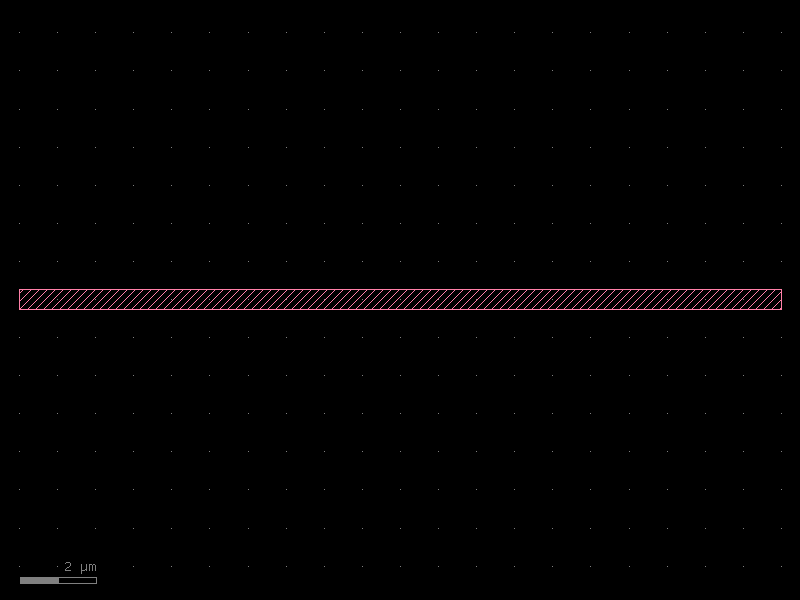

In [4]:
target = kf.KCell("wg_from_virtual", kcl=pdk)
vi = kf.VInstance(vc_wg)
vi.insert_into(target)

print(f"Real cell name  : {target.name}")
print(f"Real cell bbox  : {target.dbbox()} µm")
target.plot()

## Nesting VKCells

VKCells can contain instances of other VKCells.  The whole hierarchy is flattened
into real KLayout cells when `insert_into` is called on the outermost level.

parent bbox (µm): (0,-0.25;30,2.25)


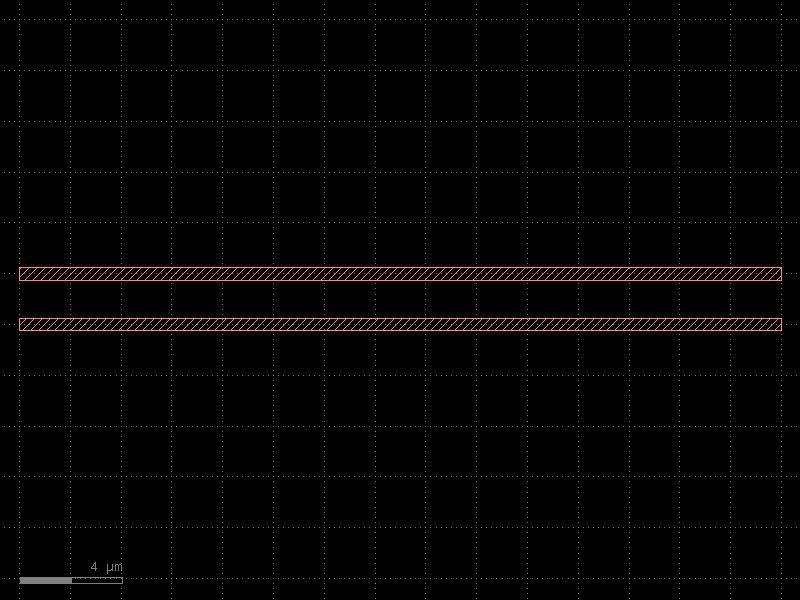

In [5]:
# Build two virtual waveguide arms
arm_a = pdk.vkcell(name="arm_a")
arm_a.shapes(wg_layer).insert(kf.kdb.DBox(0, -0.25, 30.0, 0.25))

arm_b = pdk.vkcell(name="arm_b")
arm_b.shapes(wg_layer).insert(kf.kdb.DBox(0, -0.25, 30.0, 0.25))

# Compose them inside a parent virtual cell
parent_vc = pdk.vkcell(name="virtual_composed")
inst_a = parent_vc.create_inst(cell=arm_a)  # at (0, 0)
inst_b = parent_vc.create_inst(
    cell=arm_b,
    trans=kf.kdb.DCplxTrans(1, 0, False, 0.0, 2.0),  # shift 2 µm up
)

print(f"parent bbox (µm): {parent_vc.dbbox()}")

# Materialise the whole hierarchy at once
c_composed = kf.KCell("composed_from_virtual", kcl=pdk)
kf.VInstance(parent_vc).insert_into(c_composed)
c_composed.plot()

## `@kf.vcell` decorator

For reusable virtual component factories use the `@pdk.vcell` decorator — it
works like `@pdk.cell` but returns a `VKCell` and caches by parameter hash.

In [6]:
@pdk.vcell
def virtual_straight(
    width: float,
    length: float,
    layer: kf.kdb.LayerInfo,
) -> kf.VKCell:
    c = pdk.vkcell()
    lyr = pdk.layer(layer)
    half_w = width / 2
    c.shapes(lyr).insert(kf.kdb.DBox(0, -half_w, length, half_w))
    c.create_port(
        name="o1",
        dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, 0.0, 0.0),
        width=width,
        layer=lyr,
    )
    c.create_port(
        name="o2",
        dcplx_trans=kf.kdb.DCplxTrans(1, 0, False, length, 0.0),
        width=width,
        layer=lyr,
    )
    return c


s1 = virtual_straight(width=0.5, length=10.0, layer=L.WG)
s2 = virtual_straight(width=0.5, length=10.0, layer=L.WG)  # cached

print(f"s1 is s2 (cached): {s1 is s2}")
print(f"s1 bbox : {s1.dbbox(pdk.layer(L.WG))} µm")

s1 is s2 (cached): True
s1 bbox : (0,-0.25;10,0.25) µm


## Virtual factories

kfactory ships built-in virtual factories for straight waveguides and euler bends.
These are the building blocks for all-angle routing (see
[All-Angle Routing](../../routing/all_angle.py)).

| Factory | Source module | Parameter units |
|---|---|---|
| `virtual_straight_factory(kcl)` | `kfactory.factories.virtual.straight` | µm |
| `virtual_bend_euler_factory(kcl)` | `kfactory.factories.virtual.euler` | µm |

In [7]:
_v_straight_raw = virtual_straight_factory(kcl=pdk)
_v_bend_raw = virtual_bend_euler_factory(kcl=pdk)

# Bind common parameters with functools.partial
v_straight = partial(_v_straight_raw, layer=L.WG)
v_bend = partial(_v_bend_raw, width=0.5, radius=10.0, layer=L.WG)

# Produce virtual components
vs = v_straight(width=0.5, length=15.0)
vb = v_bend(angle=90)

print(f"virtual straight bbox : {vs.dbbox(pdk.layer(L.WG))} µm")
print(f"virtual bend    bbox  : {vb.dbbox(pdk.layer(L.WG))} µm")
print(f"virtual bend    ports : {[p.name for p in vb.ports]}")

virtual straight bbox : (0,-0.25;15,0.25) µm
virtual bend    bbox  : (0,-0.25;18.9509584665,18.7009584665) µm
virtual bend    ports : ['o1', 'o2']


## All-angle routing into a VKCell

The most common reason to work with VKCell directly is **all-angle routing** —
computing the route in virtual space, inspecting it, then materialising once
satisfied.

Virtual route bbox (µm): (0,-0.25;160,60.25)
Ports: []


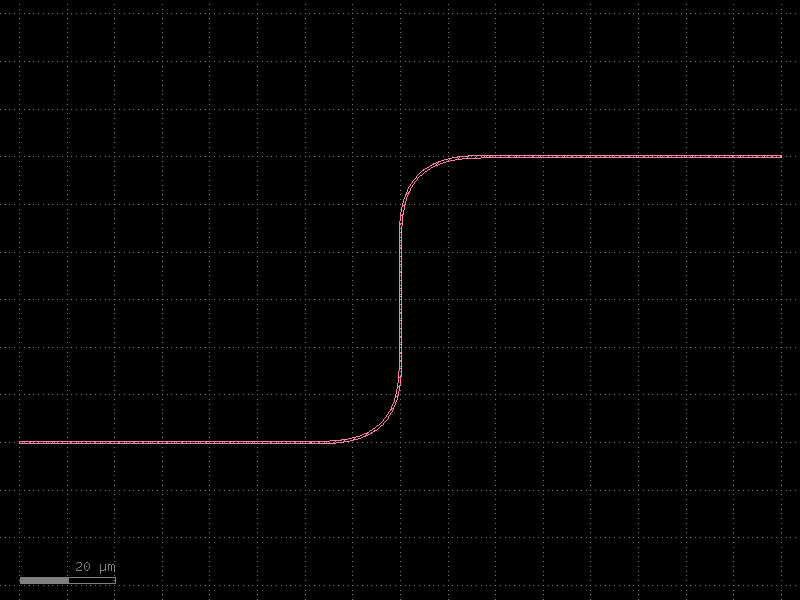

In [8]:
vc_route = pdk.vkcell(name="aa_preview")

kf.routing.aa.optical.route(
    vc_route,
    width=0.5,
    backbone=[
        kf.kdb.DPoint(0, 0),
        kf.kdb.DPoint(80, 0),
        kf.kdb.DPoint(80, 60),
        kf.kdb.DPoint(160, 60),
    ],
    straight_factory=v_straight,
    bend_factory=v_bend,
)

print(f"Virtual route bbox (µm): {vc_route.dbbox()}")
print(f"Ports: {[p.name for p in vc_route.ports]}")

# Materialise into a real cell
c_aa = kf.KCell("aa_from_vkcell", kcl=pdk)
kf.VInstance(vc_route).insert_into(c_aa)
c_aa.plot()

## `insert_into_flat`

Use `insert_into_flat` when you want the virtual geometry inlined directly into
the target cell (no sub-cell hierarchy created).

Instances in c_flat : []
c_flat bbox (µm)    : (0,-0.25;100,40.25)


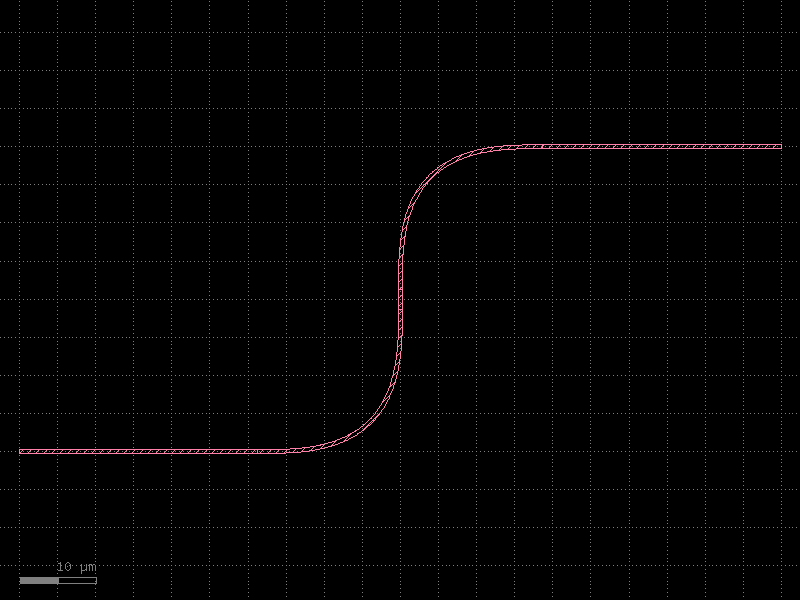

In [9]:
c_flat = kf.KCell("aa_flat", kcl=pdk)

vc_flat = pdk.vkcell(name="route_flat_src")
kf.routing.aa.optical.route(
    vc_flat,
    width=0.5,
    backbone=[
        kf.kdb.DPoint(0, 0),
        kf.kdb.DPoint(50, 0),
        kf.kdb.DPoint(50, 40),
        kf.kdb.DPoint(100, 40),
    ],
    straight_factory=v_straight,
    bend_factory=v_bend,
)

kf.VInstance(vc_flat).insert_into_flat(c_flat)

print(f"Instances in c_flat : {list(c_flat.each_inst())}")
print(f"c_flat bbox (µm)    : {c_flat.dbbox()}")
c_flat.plot()

With `insert_into_flat` all geometry lands directly in `c_flat` — no child cells
are created.

## Summary

| Operation | Code |
|---|---|
| Create VKCell | `vc = kcl.vkcell(name="...")` |
| Insert shape | `vc.shapes(layer_idx).insert(kdb.DBox(...))` |
| Add port | `vc.create_port(name=..., dcplx_trans=..., width=..., layer=...)` |
| Nest VKCells | `vc.create_inst(cell=child_vc, trans=...)` |
| Reusable factory | `@pdk.vcell` decorator |
| Materialise (hierarchical) | `kf.VInstance(vc).insert_into(target)` |
| Materialise (flat) | `kf.VInstance(vc).insert_into_flat(target)` |
| Virtual straight factory | `virtual_straight_factory(kcl=pdk)` |
| Virtual euler bend factory | `virtual_bend_euler_factory(kcl=pdk)` |

## See Also

| Topic | Where |
|-------|-------|
| PCells & caching | [Components: PCells](pcells.py) |
| Factory functions reference | [Components: Factories](factories/overview.py) |
| All-angle routing into VKCell | [Routing: All-Angle](../../routing/all_angle.py) |
| KCell / DKCell / VKCell basics | [Core Concepts: KCell](../../concepts/kcell.py) |